<a href="https://colab.research.google.com/github/Tejaswimadastu/Deep_Learning/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN
from sklearn.metrics import mean_squared_error

In [3]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
df = pd.read_csv('optimized_waste_management_data.csv')
df.head()

Saving optimized_waste_management_data.csv to optimized_waste_management_data.csv


,date,waste_volume,organic_waste,recyclable_waste,hazardous_waste,collection_frequency,landfill_capacity_used,recycling_rate
0,01-01-2020,48.85,31.49,12.55,4.81,Weekly,55.87,47.37
1,02-01-2020,49.45,29.76,14.76,4.94,Weekly,51.91,41.70
2,03-01-2020,51.03,32.29,13.65,5.09,Bi-weekly,53.08,58.73
3,04-01-2020,54.70,35.09,14.36,5.25,Bi-weekly,52.04,39.34
4,05-01-2020,51.74,29.99,16.87,4.88,Bi-weekly,48.01,40.45


In [4]:
df = df.fillna(method='ffill')

/tmp/ipykernel_3392/569672361.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [5]:
# Extract Feature to Predict
# We only use the Waste Column for forecasting
waste_data = df[['waste_volume']]

In [6]:
scaler = MinMaxScaler(feature_range = (0,1))
scaled_data = scaler.fit_transform(waste_data)

# Convert Data into Sequences

RNN requires sequential input.

Example:

Previous 10 days → Predict next day

In [10]:
def create_sequences(data, seq_length):
    X = []
    y = []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Create Time Sequences

In [11]:
sequence_length=10
X,y=create_sequences(scaled_data,sequence_length)
print(X.shape)
print(y.shape)


(1451, 10, 1)
(1451, 1)


**Build the RNN Model**

Architecture

Input -> RNN Layer -> Dense Output

In [13]:
model=Sequential()
model.add(SimpleRNN(50,activation="tanh",input_shape=(sequence_length,1)))
model.add(Dense(1))
model.compile(optimizer="adam",loss="mean_squared_error")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

# Split Data into Training and Testing Sets

In [15]:
split=int(0.8*len(X))
X_train=X[:split]
y_train=y[:split]
X_test=X[split:]
y_test=y[split:]

# Train the Model

We train the model for 50 epochs

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1
)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 0.0204 - val_loss: 0.0158
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0102 - val_loss: 0.0116
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0097 - val_loss: 0.0118
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0096 - val_loss: 0.0112
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0095 - val_loss: 0.0110
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0094 - val_loss: 0.0130
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0094 - val_loss: 0.0198
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0102 - val_loss: 0.0114
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0096 - val_loss: 0.0112
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0094 - val_loss: 0.0150
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0096 - val_loss: 0.0151
Epoch 12/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0094 - val_l

# Evaluate the Model

In [17]:
loss = model.evaluate(X_test, y_test)
print("Test Loss:", loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0093
Test Loss: 0.009252875111997128


In [18]:
predictions = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


# Convert Predictions Back to Original Scale

In [19]:
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test)

# Plot predictions vs Actual Values

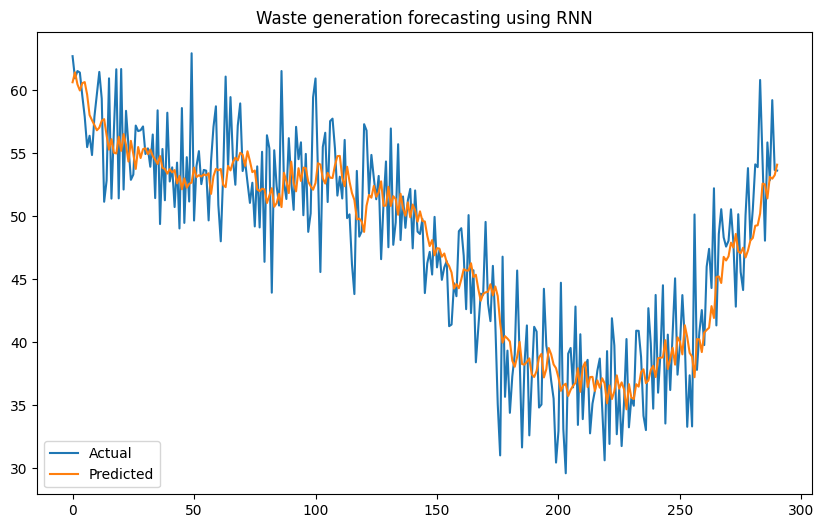

In [22]:
plt.figure(figsize=(10,6))
plt.plot(y_test, label='Actual')
plt.plot(predictions, label='Predicted')
plt.title("Waste generation forecasting using RNN")
plt.legend()
plt.show()
# Two lines are close - good model